# Análisis del catálogo de Netflix: datos, limpieza y exploración en Python

En este notebook voy a trabajar con un csv de películas y series de Netflix.

La idea principal no es solo hacer gráficos o modelos, sino aprender a trabajar con datos reales, que muchas veces vienen incompletos, desordenados o con formatos que no sirven directamente.

In [208]:
!pip install statsmodels
!pip install scikit-learn

In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Carga de datos:

El dataset contiene información como:

* tipo de contenido (película o serie),
* título,
* director,
* elenco,
* país,
* fecha en que se agregó a Netflix,
* año de lanzamiento,
* clasificación,
* duración,
* géneros.

Primero cargo el archivo y reviso cuántas filas y columnas tiene, además de ver cómo vienen los datos.

In [210]:
#Carga de datos:

REPO_ROOT = Path.cwd() if (Path.cwd() / "Netflix_Datos").exists() else Path.cwd().parent
DATA_PATH = REPO_ROOT / "Netflix_Datos" / "netflix_titles.csv"

dfn = pd.read_csv(DATA_PATH)

print("\nFilas y columnas:", dfn.shape)
print("\n---------------------------------------------------------------------------------------------------------------")
dfn.head()


Filas y columnas: (8807, 12)

---------------------------------------------------------------------------------------------------------------


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#

## Revisión inicial de los datos

Antes de hacer cualquier cambio, reviso:

* los nombres de las columnas,
* los tipos de datos,
* si hay valores faltantes,
* y un resumen general.

Aquí empiezo a notar varios problemas:

* faltan muchos datos en columnas como director, cast y country,
* la columna date_added está como texto,
* y duration mezcla cosas como "90 min" y "2 Seasons".

Esto me sirve para saber qué tengo que arreglar después.

In [211]:
print("\nDatos disponibles:")

print("\nColumnas:")
print(dfn.columns.tolist())

print("\n---------------------------------------------------------------------------------------------------------------")

print("\nResumen numérico:")
display(dfn.describe())

print("\n---------------------------------------------------------------------------------------------------------------")

ntn= dfn.isnull().sum()
ntn_pct = (ntn / len(dfn) * 100 ).round(1)

print("\nResumen de valores faltantes, tipo de datos y valores completos:\n")
info = pd.DataFrame({
    "Conteo_Nulos:": ntn,
    "Porcentaje: ": ntn_pct,
    "Conteo_NoNulos:": dfn.notnull().sum(),
    "Tipo_datos:": dfn.dtypes
})

info = info.sort_values(by="Conteo_Nulos:", ascending=False).T


display(info)



Datos disponibles:

Columnas:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

---------------------------------------------------------------------------------------------------------------

Resumen numérico:


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000



---------------------------------------------------------------------------------------------------------------

Resumen de valores faltantes, tipo de datos y valores completos:



,director,country,cast,date_added,rating,duration,show_id,type,title,release_year,listed_in,description
Conteo_Nulos:,2634,831,825,10,4,3,0,0,0,0,0,0
Porcentaje:,29.9,9.4,9.4,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conteo_NoNulos:,6173,7976,7982,8797,8803,8804,8807,8807,8807,8807,8807,8807
Tipo_datos:,str,str,str,str,str,str,str,str,str,int64,str,str


Seguimos conociendo un poco de lo que posee el csv, en cuestion de cantidad/conteo de algunas columnas:

In [212]:
tab_tp = pd.DataFrame({
    "Valores posibles": dfn["type"].unique()
})

display(tab_tp)

,Valores posibles
0,Movie
1,TV Show


In [213]:
print("\nAños en existencia:\n")
dfn["release_year"].unique()


Años en existencia:



array([2020, 2021, 1993, 2018, 1996, 1998, 1997, 2010, 2013, 2017, 1975,
       1978, 1983, 1987, 2012, 2001, 2014, 2002, 2003, 2004, 2011, 2008,
       2009, 2007, 2005, 2006, 1994, 2015, 2019, 2016, 1982, 1989, 1990,
       1991, 1999, 1986, 1992, 1984, 1980, 1961, 2000, 1995, 1985, 1976,
       1959, 1988, 1981, 1972, 1964, 1945, 1954, 1979, 1958, 1956, 1963,
       1970, 1973, 1925, 1974, 1960, 1966, 1971, 1962, 1969, 1977, 1967,
       1968, 1965, 1946, 1942, 1955, 1944, 1947, 1943])

In [214]:
print("\nCantidades existentes por año:\n")
dfn["release_year"].value_counts().to_frame().T


Cantidades existentes por año:



release_year,2018,2017,2019,2020,2016,2021,2015,2014,2013,2012,...,1970,1969,1965,1946,1942,1961,1959,1925,1966,1947
count,1147,1032,1030,953,902,592,560,352,288,237,...,2,2,2,2,2,1,1,1,1,1


In [215]:
print("\nContenido por pais:\n")
dfn["country"].value_counts().to_frame()


Contenido por pais:



,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
...,...
"Russia, Spain",1
"Croatia, Slovenia, Serbia, Montenegro",1
"Japan, Canada",1


In [216]:
print("\nCantidad de categorias:\n")
dfn["listed_in"].value_counts().to_frame().T


Cantidad de categorias:



listed_in,"Dramas, International Movies",Documentaries,Stand-Up Comedy,"Comedies, Dramas, International Movies","Dramas, Independent Movies, International Movies",Kids' TV,Children & Family Movies,"Children & Family Movies, Comedies","Documentaries, International Movies","Dramas, International Movies, Romantic Movies",...,"Children & Family Movies, Faith & Spirituality","Classic Movies, Comedies, Sports Movies","Comedies, Dramas, Sports Movies","Action & Adventure, Romantic Movies, Sci-Fi & Fantasy","Classic & Cult TV, TV Sci-Fi & Fantasy","Comedies, Cult Movies, LGBTQ Movies","Action & Adventure, Comedies, Horror Movies","Classic & Cult TV, Crime TV Shows, TV Dramas","Action & Adventure, Documentaries, Sports Movies","Cult Movies, Dramas, Thrillers"
count,362,359,334,274,252,220,215,201,186,180,...,1,1,1,1,1,1,1,1,1,1


In [217]:
print("\nCantidades existentes de cada clasificación:\n")
dfn["rating"].value_counts().to_frame().T


Cantidades existentes de cada clasificación:



rating,TV-MA,TV-14,TV-PG,R,PG-13,TV-Y7,TV-Y,PG,TV-G,NR,G,TV-Y7-FV,NC-17,UR,74 min,84 min,66 min
count,3207,2160,863,799,490,334,307,287,220,80,41,6,3,3,1,1,1


#

## Auditoría de calidad

En esta parte reviso cosas más específicas:

* si hay filas duplicadas,
* cómo se distribuyen los valores en columnas como type y rating,
* y cómo viene exactamente la duración.

Aquí confirmo que duration está mezclando formatos, lo cual puede causar problemas si quiero analizarla.

In [218]:
#Contar peliculas y series
conteo= dfn["type"].value_counts()
conteo_pct= dfn["type"].value_counts(normalize=True) * 100

info = pd.DataFrame({
    "Cantidad:": conteo,
    "Porcentaje (%):": conteo_pct.round(2)
}).T

display(info)

type,Movie,TV Show
Cantidad:,6131.00,2676.00
Porcentaje (%):,69.62,30.38


In [219]:
print("\nCantidad de duplicados:")
duplicados = dfn.duplicated().sum()
print(duplicados)


Cantidad de duplicados:
0


In [220]:
# Verificacion de mezclas de formatos
print("Duración ejemplos:")
print(dfn["duration"].head(10))

Duración ejemplos:
0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
6       91 min
7      125 min
8    9 Seasons
9      104 min
Name: duration, dtype: str


In [221]:
print("\nTitulos repetidos:")
Ttl_dup = dfn.duplicated().sum()
print(Ttl_dup)


Titulos repetidos:
0


In [222]:
print("\nAños invalidos:")
año = pd.DataFrame({
    "Cantidad": [(dfn["release_year"] < 1900).sum()]
})

display(año)


Años invalidos:


,Cantidad
0,0


In [223]:
print("\nRevición de valores diferentes por columna:")
dfn.nunique().to_frame().T


Revición de valores diferentes por columna:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,8807,2,8807,4528,7692,748,1767,74,17,220,514,8775


In [224]:
print("\nCantidad de directores:")
dfn["director"].nunique()


Cantidad de directores:


4528

In [225]:
#faltantes de cada columna:
auditoria = pd.DataFrame({
    "faltantes": ntn,
    "porcentaje": ntn_pct,
    "tipo": dfn.dtypes
})

auditoria.sort_values(
    "porcentaje",
    ascending=False
)

,faltantes,porcentaje,tipo
director,2634,29.9,str
cast,825,9.4,str
country,831,9.4,str
date_added,10,0.1,str
title,0,0.0,str
type,0,0.0,str
show_id,0,0.0,str
release_year,0,0.0,int64
rating,4,0.0,str
duration,3,0.0,str


#

## Limpieza de datos

Ahora sí empiezo a limpiar.

Hago lo siguiente:

* convierto date_added a formato de fecha para poder trabajar con años,
* separo duration en dos columnas:

  * una con el número (duration_num),
  * otra con el tipo (min o seasons),
* relleno los valores faltantes en director, cast y country con "Desconocido",
* y creo una nueva columna llamada year_added a partir de la fecha, y de la misma forma con los meses.
* Finalmente, tambien indico que algunas columnas no son textos libres, si no categorias.

Todo esto lo hago para que los datos sean más fáciles de analizar y más consistentes.

In [226]:
# Crear copia del dataset
dfn_copia = dfn.copy()

In [227]:
#Replazar valores faltantes:
dfn_copia["director"] = dfn_copia["director"].fillna("Desconocido")
dfn_copia["cast"] = dfn_copia["cast"].fillna("Desconocido")
dfn_copia["country"] = dfn_copia["country"].fillna("Desconocido")

dfn_copia[["director","cast","country"]].head()

,director,cast,country
0,Kirsten Johnson,Desconocido,United States
1,Desconocido,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa
2,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Desconocido
3,Desconocido,Desconocido,Desconocido
4,Desconocido,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India


In [228]:
#conversion de fechas:

dfn_copia["date_added"] = pd.to_datetime(
    dfn_copia["date_added"],
    errors="coerce"
)
dfn_copia[["date_added"]].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [229]:
#Extraer numero de duracion

dfn_copia["duration_num"] = dfn_copia["duration"].str.extract(r"(\d+)").astype(float)

dfn_copia["duration_type"] = dfn_copia["duration"].str.extract(r"([a-zA-Z]+)")

dfn_copia[["duration","duration_num","duration_type"]].head()

,duration,duration_num,duration_type
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons


In [249]:
#convertir columnas de textos repetidos en categorias:

dfn_copia["type"] = dfn_copia["type"].astype("category")

dfn_copia["rating"] = dfn_copia["rating"].astype("category")

dfn_copia["country"] = dfn_copia["country"].astype("category")



dfn_copia[["type","rating","country"]].head()

,type,rating,country
0,Movie,PG-13,United States
1,TV Show,TV-MA,South Africa
2,TV Show,TV-MA,Desconocido
3,TV Show,TV-MA,Desconocido
4,TV Show,TV-MA,India


In [230]:
print("\nExtraccion de años:")

dfn_copia["year_added"] = dfn_copia["date_added"].dt.year

dfn_copia[["year_added"]].head()


Extraccion de años:


,year_added
0,2021.0
1,2021.0
2,2021.0
3,2021.0
4,2021.0


In [231]:
print("\nExtraccion de meses:")

dfn_copia["month_added"] = dfn_copia["date_added"].dt.month
dfn_copia[["month_added"]].head()


Extraccion de meses:


,month_added
0,9.0
1,9.0
2,9.0
3,9.0
4,9.0


In [232]:
#Verificar limpieza:
dfn_copia.isnull().sum().to_frame()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,4
duration,3


In [250]:
#Verificar tipos de datos:
dfn_copia.dtypes.to_frame()

,0
show_id,str
type,category
title,str
director,str
cast,str
country,category
date_added,datetime64[us]
release_year,int64
rating,category
duration,str


In [234]:
print("--------  Antes  -----------")
dfn.isnull().sum()

--------  Antes  -----------


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [235]:
print("--------  Despues  -----------")
dfn_copia.isnull().sum()

--------  Despues  -----------


show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       98
release_year      0
rating            4
duration          3
listed_in         0
description       0
duration_num      3
duration_type     3
year_added       98
month_added      98
dtype: int64

In [236]:
dfn_copia.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,duration_type,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Desconocido,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,2021.0,9.0
1,s2,TV Show,Blood & Water,Desconocido,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons,2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Desconocido,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Desconocido,Desconocido,Desconocido,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021.0,9.0
4,s5,TV Show,Kota Factory,Desconocido,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons,2021.0,9.0


#

## Creacion de variables

Después creo algunas columnas nuevas para poder analizar mejor:

* is_movie: para saber si es película (1) o serie (0),
* num_genres: cuántos géneros tiene cada contenido,
* has_director: para saber si se conoce el director o no.
* etc, etc.

Estas variables no vienen en el dataset original, pero ayudan mucho a entender mejor la información.

In [237]:
## tiempo desde la creacion del contenido:
from datetime import datetime
dfn_copia["content_age"] = datetime.now().year - dfn_copia["release_year"]

##Cantidad de paises:
dfn_copia["country_count"] = dfn_copia["country"].str.split(",").str.len()

##Cantidad de actores:
dfn_copia["cast_count"] = dfn_copia["cast"].str.split(",").str.len()

## Cantidad de generos:
dfn_copia["genre_count"] = dfn_copia["listed_in"].str.split(",").str.len()

## Longitud de la descripcion:
dfn_copia["description_length"] = dfn_copia["description"].str.len()

## ¿Hay director?:
dfn_copia["has_director"] = dfn_copia["director"] != "Desconocido"

## ¿Es pelicula?:
dfn_copia["is_movie"] = dfn_copia["duration_type"] == "min"

dfn_copia[["title","content_age","country_count","cast_count","genre_count","description_length","has_director","is_movie"]].head()

,title,content_age,country_count,cast_count,genre_count,description_length,has_director,is_movie
0,Dick Johnson Is Dead,6,1,1,1,152,True,True
1,Blood & Water,5,1,19,3,147,False,False
2,Ganglands,5,1,9,3,146,True,False
3,Jailbirds New Orleans,5,1,1,2,147,False,False
4,Kota Factory,5,1,8,3,152,False,False


#

## ANALISIS DE EXPLORACION DE DATOS

Aquí empiezo a hacer gráficas para ver patrones.

Por ejemplo:

* cuántas películas vs series hay,
* cómo ha crecido el catálogo con el tiempo,
* cómo se distribuyen las duraciones.
* etc.
    

Las gráficas me ayudan a entender los datos más rápido que solo viendo números.

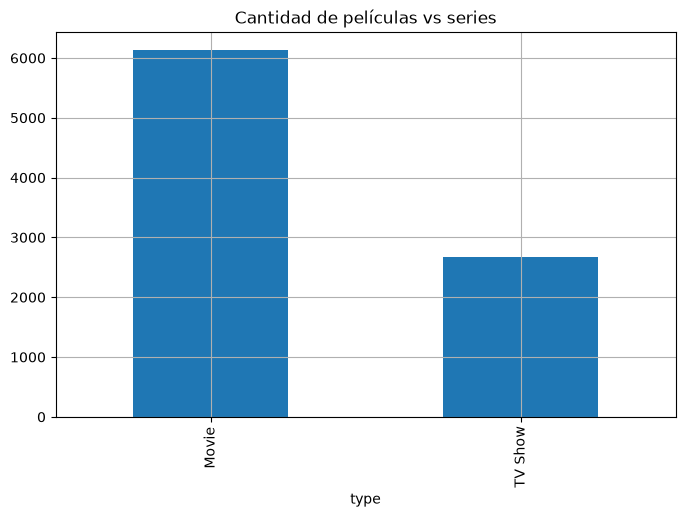

In [238]:
#¿cuántas películas vs series hay?
dfn_copia["type"].value_counts().plot(kind="bar")
plt.title("Cantidad de películas vs series")
plt.show()

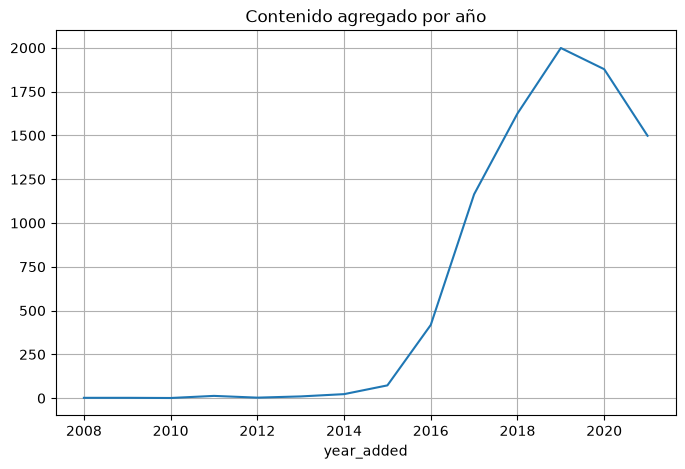

In [239]:
#¿Cuanto se agrego cada año?
dfn_copia["year_added"].value_counts().sort_index().plot()
plt.title("Contenido agregado por año")
plt.show()

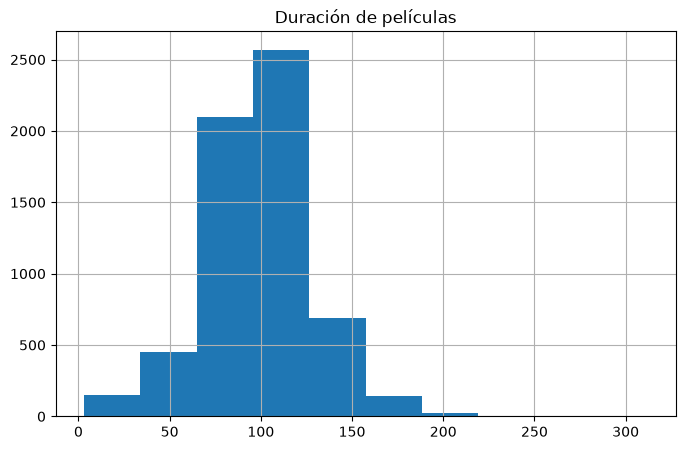

In [240]:
#¿cuanto duran las peliculas?
dfn_copia[dfn_copia["duration_type"] == "min"]["duration_num"].hist()
plt.title("Duración de películas")
plt.show()

In [241]:
#Predicion del tipo, se trata se adivinar si es pelicula o serie
X = dfn_copia[["release_year", "duration_num", "genre_count"]].fillna(0)
y = dfn_copia["is_movie"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [242]:
print("Muestra de las primeras 10 predicciones:\n")
print(preds[:10])

Muestra de las primeras 10 predicciones:

[ True  True  True  True False  True False  True False False]


In [243]:
from sklearn.metrics import accuracy_score
print("Nivel de precisión:", accuracy_score(y_test, preds))

Nivel de precisión: 1.0


In [244]:
import pandas as pd

## Comparación del real vs predicho
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": preds
})

display(comparacion.head(10))

,Real,Predicho
0,True,True
1,True,True
2,True,True
3,True,True
4,False,False
5,True,True
6,False,False
7,True,True
8,False,False
9,False,False


In [245]:
#Paises con mas contenido
dfn_copia["country"].value_counts().head(10).to_frame().T

country,United States,India,Desconocido,United Kingdom,Japan,South Korea,Canada,Spain,France,Mexico
count,2818,972,831,419,245,199,181,145,124,110


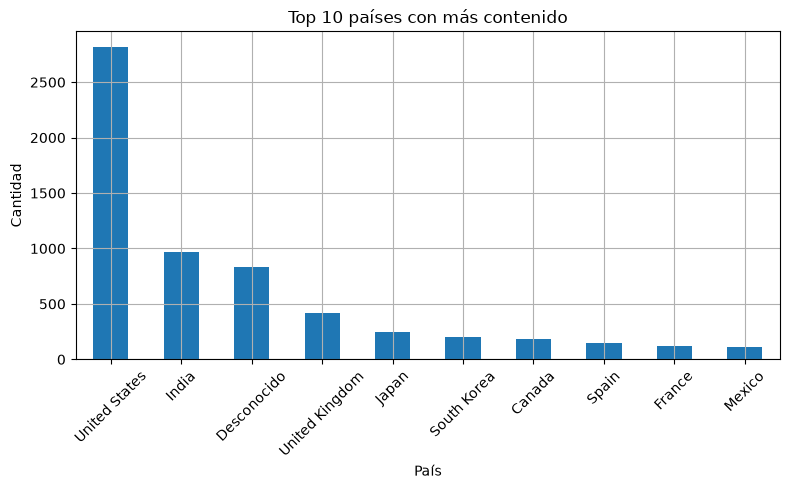

In [246]:
import matplotlib.pyplot as plt

paises = dfn_copia["country"].value_counts().head(10)

plt.figure()
paises.plot(kind='bar')

plt.title("Top 10 países con más contenido")
plt.xlabel("País")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

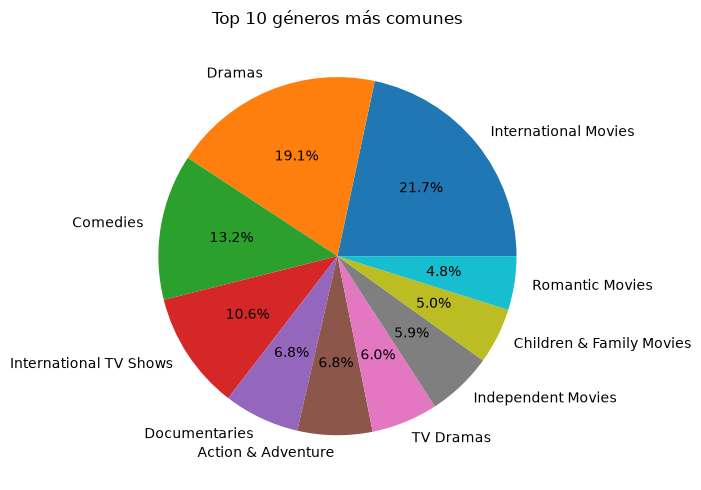

In [247]:
import matplotlib.pyplot as plt

# Separar géneros correctamente
dfn_copia["listed_in"] = dfn_copia["listed_in"].str.split(", ")
df_exploded = dfn_copia.explode("listed_in")

# Top 10 géneros
top_genres = df_exploded["listed_in"].value_counts().head(10)

# Gráfica de pastel
plt.figure()
top_genres.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top 10 géneros más comunes")
plt.ylabel("")  # quitar etiqueta fea de eje

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

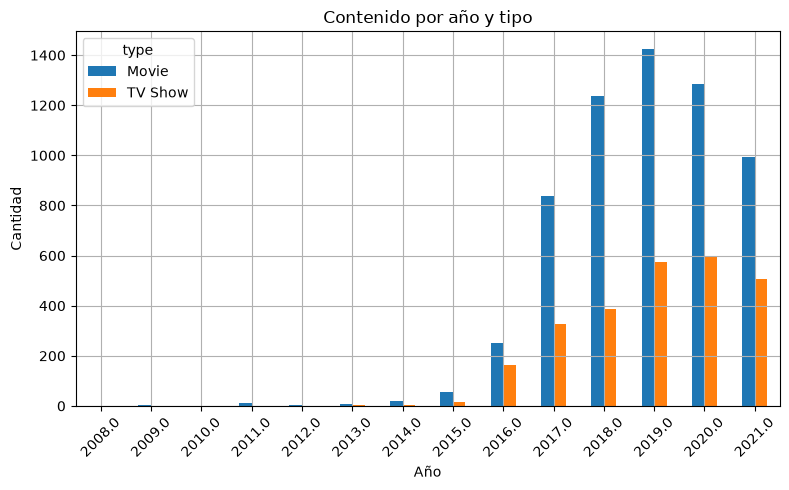

In [248]:
import matplotlib.pyplot as plt
import pandas as pd

tabla = pd.crosstab(dfn_copia["year_added"], dfn_copia["type"])

plt.figure()
tabla.plot(kind='bar')

plt.title("Contenido por año y tipo")
plt.xlabel("Año")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##

## Conclusiones

Después de todo el proceso, puedo ver que:

los datos necesitaban bastante limpieza antes de usarlos,
era importante separar y convertir algunos formatos,
crear nuevas variables ayudó a entender mejor el dataset,
y las visualizaciones permitieron ver patrones interesantes.

En general, este ejercicio me ayuda a entender que trabajar con datos no es solo analizarlos, sino también prepararlos bien desde el inicio.